# 00 — EDA Inicial: Análisis Exploratorio de los Datasets de Obra

**Proyecto:** Sistema de Detección de Riesgos de Corrupción en Obras Públicas mediante Machine Learning  
**Tesis:** Maestría en Inteligencia Artificial – UNI  
**Autor:** Fernando García Atúncar  
**Versión:** v1.0 — Sprint 2

---

## Propósito de este notebook

Este notebook constituye el **punto de entrada al pipeline de datos**.  
Su objetivo es documentar, validar y comprender los **8 datasets fuente** (DS_DASH_Obra_*)  
antes de construir cualquier feature o entrenar cualquier modelo.

Responde tres preguntas clave:

1. ¿Qué contiene cada dataset? (estructura, tipos, nulos)  
2. ¿Cómo se relacionan entre sí? (llaves, cardinalidades)  
3. ¿Qué señales de riesgo ya son visibles en los datos crudos?

---

## Datasets analizados

| Alias | Archivo | Filas | Cols | Descripción |
|-------|---------|-------|------|-------------|
| o1a   | DS_DASH_Obra_1A.csv   | 326   | 12 | Convocatoria / proceso licitatorio base |
| o2a3a | DS_DASH_Obra_2A_3A.csv | 552  | 22 | Ganador + contrato firmado |
| o2b   | DS_DASH_Obra_2B.csv   | 1 613 |  6 | Miembros del comité de selección |
| o3b   | DS_DASH_Obra_3B.csv   | 5 249 | 20 | Todos los postores por contrato |
| o3c   | DS_DASH_Obra_3C.csv   | 5 249 |  8 | Montos ofertados por postor |
| o4a   | DS_DASH_Obra_4A.csv   | 326   |  9 | Estado actual de la obra |
| o4b   | DS_DASH_Obra_4B.csv   | 326   | 15 | Control, etapa y nivel de riesgo (**TARGET**) |
| o5a   | DS_DASH_Obra_5A.csv   | 634   | 15 | Avance físico mensual (planificado vs real) |


## PASO 0 — Imports y configuración

In [ ]:
# ============================================================
# IMPORTS
# ============================================================

from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

print("✅ Imports OK")


✅ Imports OK


In [ ]:
# ============================================================
# RUTAS — ajusta BASE según tu entorno
# ============================================================

BASE = Path(r"C:\IA_Investigacion\Deteccion_Corrupcion")

DATA_EXT = BASE / "data" / "external" / "obra"

FILES_OBRA = {
    "o1a":   "DS_DASH_Obra_1A.csv",
    "o2a3a": "DS_DASH_Obra_2A_3A.csv",
    "o2b":   "DS_DASH_Obra_2B.csv",
    "o3b":   "DS_DASH_Obra_3B.csv",
    "o3c":   "DS_DASH_Obra_3C.csv",
    "o4a":   "DS_DASH_Obra_4A.csv",
    "o4b":   "DS_DASH_Obra_4B.csv",
    "o5a":   "DS_DASH_Obra_5A.csv",
}

print("Ruta base:", BASE)
print("Ruta datos:", DATA_EXT)


Ruta base: C:\IA_Investigacion\Deteccion_Corrupcion
Ruta datos: C:\IA_Investigacion\Deteccion_Corrupcion\data\external\obra


---
## PASO 1 — Carga de datasets

Función robusta que prueba múltiples encodings y normaliza nombres de columnas.


In [ ]:
# ============================================================
# FUNCIONES DE CARGA
# ============================================================

def read_csv_robust(path: Path) -> pd.DataFrame:
    """Lee CSV probando encodings comunes."""
    encodings = ["utf-8", "utf-8-sig", "latin1", "cp1252"]
    for enc in encodings:
        try:
            df = pd.read_csv(path, encoding=enc)
            df.attrs["encoding"] = enc
            return df
        except Exception:
            continue
    raise ValueError(f"No se pudo leer: {path}")


def normalize_cols(df: pd.DataFrame) -> pd.DataFrame:
    """Normaliza nombres de columnas a SNAKE_UPPER."""
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace("\ufeff", "", regex=False)
        .str.replace(" ", "_", regex=False)
        .str.upper()
    )
    return df


# ============================================================
# CARGA DE TODOS LOS DATASETS
# ============================================================

tablas_obra = {}

for alias, fname in FILES_OBRA.items():
    path = DATA_EXT / fname
    df = read_csv_robust(path)
    df = normalize_cols(df)
    tablas_obra[alias] = df
    print(f"✅ {alias:8s} | {df.shape[0]:>5,} filas × {df.shape[1]:>2} cols | enc={df.attrs.get('encoding')}")


✅ o1a      |   326 filas × 12 cols | enc=latin1
✅ o2a3a    |   552 filas × 22 cols | enc=latin1
✅ o2b      | 1,613 filas ×  6 cols | enc=latin1
✅ o3b      | 5,249 filas × 20 cols | enc=latin1
✅ o3c      | 5,249 filas ×  8 cols | enc=latin1
✅ o4a      |   326 filas ×  9 cols | enc=latin1
✅ o4b      |   326 filas × 15 cols | enc=latin1
✅ o5a      |   634 filas × 15 cols | enc=latin1


---
## PASO 2 — Inventario general de columnas y nulos

Para cada dataset: shape, columnas, tipos de dato y porcentaje de nulos.


In [ ]:
# ============================================================
# INVENTARIO GENERAL
# ============================================================

inventario = []

for alias, df in tablas_obra.items():
    for col in df.columns:
        pct_nulo = df[col].isna().mean() * 100
        inventario.append({
            "dataset":   alias,
            "columna":   col,
            "dtype":     str(df[col].dtype),
            "n_unicos":  df[col].nunique(dropna=True),
            "pct_nulo":  round(pct_nulo, 1),
        })

inv_df = pd.DataFrame(inventario)

print("Total columnas en todos los datasets:", len(inv_df))
print()

# Mostrar por dataset
for alias in FILES_OBRA:
    subset = inv_df[inv_df["dataset"] == alias]
    print("=" * 70)
    print(f"  {alias.upper()} — {tablas_obra[alias].shape}")
    print("=" * 70)
    display(subset[["columna", "dtype", "n_unicos", "pct_nulo"]].reset_index(drop=True))


Total columnas en todos los datasets: 107

  O1A — (326, 12)


,columna,dtype,n_unicos,pct_nulo
0,CODIGO_UNICO,int64,170,0.00
1,SECTOR,object,19,0.00
2,DEPARTAMENTO,object,23,0.00
3,NIVEL_GOBIERNO,object,3,0.00
4,IDENTIFICADOR_OBRA,object,326,0.00
5,PROCESO,int64,65,0.00
6,OBJETO_PROCESO,object,2,0.00
7,CODIGO_OBRA,int64,232,0.00
8,NOMBREOBRA,object,232,0.00
9,METODO_CONTRATACION,object,10,0.00


  O2A3A — (552, 22)


,columna,dtype,n_unicos,pct_nulo
0,CODIGO_UNICO,int64,168,0.00
1,SECTOR,object,19,0.00
2,DEPARTAMENTO,object,23,0.00
3,NIVEL_GOBIERNO,object,3,0.00
4,IDENTIFICADOR_OBRA,object,324,0.00
5,PROCESO,int64,65,0.00
6,OBJETO_PROCESO,object,2,0.00
7,CODIGO_OBRA,int64,230,0.00
8,NOMBREOBRA,object,230,0.00
9,METODO_CONTRATACION,object,10,0.00


  O2B — (1613, 6)


...

,columna,dtype,n_unicos,pct_nulo
0,CODIGO_UNICO,int64,170,0.00
1,SECTOR,object,19,0.00
2,DEPARTAMENTO,object,23,0.00
3,NIVEL_GOBIERNO,object,3,0.00
4,CODIGO_OBRA,int64,232,0.00
5,NOMBRE_OBRA,object,232,0.00
6,EMPRESA_EJECUTORA,object,42,73.00
7,EMPRESA_SUPERVISORA,object,90,48.20
8,ESTADO_OBRA,object,5,0.00


  O4B — (326, 15)


,columna,dtype,n_unicos,pct_nulo
0,CODIGO_UNICO,int64,170,0.00
1,SECTOR,object,19,0.00
2,DEPARTAMENTO,object,23,0.00
3,NIVEL_GOBIERNO,object,3,0.00
4,IDENTIFICADOR_OBRA,object,326,0.00
5,CODIGO_OBRA,int64,232,0.00
6,NOMBRE_OBRA,object,232,0.00
7,ESTADO_OBRA,object,5,0.00
8,ETAPA,object,5,0.00
9,DIAS_PLAZO,int64,39,0.00


  O5A — (634, 15)


,columna,dtype,n_unicos,pct_nulo
0,CODIGO_UNICO,int64,170,0.00
1,SECTOR,object,19,0.00
2,DEPARTAMENTO,object,23,0.00
3,NIVEL_GOBIERNO,object,3,0.00
4,IDENTIFICADOR_OBRA,object,326,0.00
5,ANHO,float64,1,40.40
6,MES,float64,8,40.40
7,PLANIFICADO,float64,78,0.00
8,REAL,float64,80,0.00
9,IND_INTERVENSION,object,1,0.00


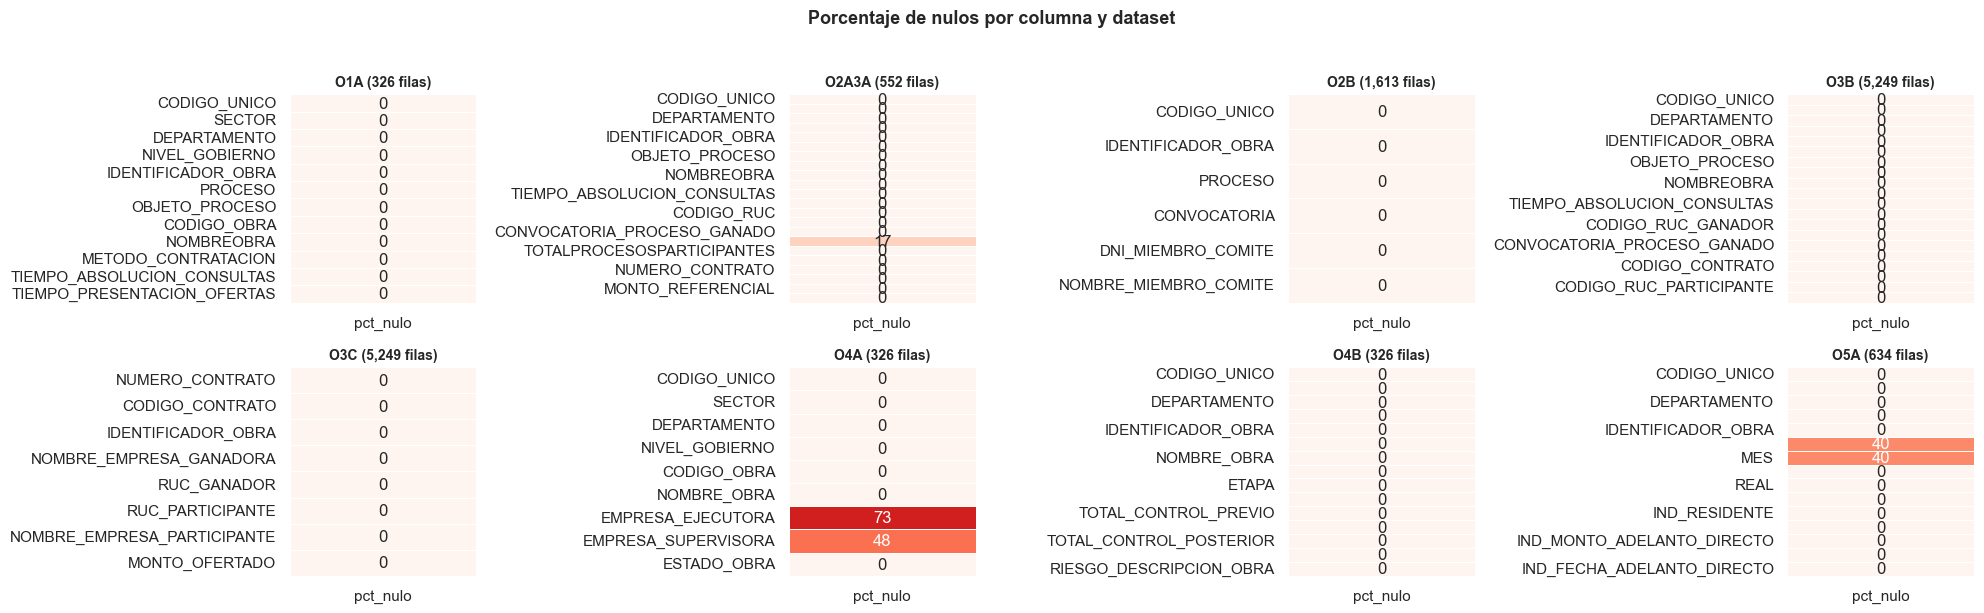

In [ ]:
# ============================================================
# RESUMEN HEATMAP DE NULOS
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(20, 6))
axes = axes.flatten()

for i, (alias, df) in enumerate(tablas_obra.items()):
    nulos = (df.isna().mean() * 100).to_frame("pct_nulo")
    sns.heatmap(
        nulos,
        ax=axes[i],
        vmin=0, vmax=100,
        cmap="Reds",
        annot=True, fmt=".0f",
        cbar=False,
        linewidths=0.5,
    )
    axes[i].set_title(f"{alias.upper()} ({df.shape[0]:,} filas)", fontsize=10, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

plt.suptitle("Porcentaje de nulos por columna y dataset", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


---
## PASO 3 — Análisis de llaves y relaciones

Verificamos unicidad y cardinalidad de las llaves candidatas en cada tabla.

| Llave | Rol |
|-------|-----|
| `CODIGO_UNICO` | Identificador de la obra (PK conceptual) |
| `IDENTIFICADOR_OBRA` | Identificador compuesto obra+proceso+contrato |
| `CODIGO_OBRA` | Código de la obra física |
| `CODIGO_CONTRATO` | Clave del contrato firmado |


In [ ]:
# ============================================================
# UNICIDAD DE LLAVES CANDIDATAS
# ============================================================

candidate_keys = [
    "CODIGO_UNICO",
    "IDENTIFICADOR_OBRA",
    "CODIGO_OBRA",
    "CODIGO_CONTRATO",
]

rows = []

for alias, df in tablas_obra.items():
    for col in candidate_keys:
        if col not in df.columns:
            continue
        n_total  = len(df)
        n_unique = df[col].nunique(dropna=True)
        rows.append({
            "dataset":       alias,
            "llave":         col,
            "filas":         n_total,
            "valores_unicos": n_unique,
            "pct_unicidad":  round(n_unique / n_total * 100, 1),
        })

keys_df = pd.DataFrame(rows)

display(
    keys_df.sort_values(["dataset", "pct_unicidad"], ascending=[True, False])
    .reset_index(drop=True)
)


,dataset,llave,filas,valores_unicos,pct_unicidad
0,o1a,IDENTIFICADOR_OBRA,326,326,100.00
1,o1a,CODIGO_OBRA,326,232,71.20
2,o1a,CODIGO_UNICO,326,170,52.10
3,o2a3a,IDENTIFICADOR_OBRA,552,324,58.70
4,o2a3a,CODIGO_CONTRATO,552,316,57.20
5,o2a3a,CODIGO_OBRA,552,230,41.70
6,o2a3a,CODIGO_UNICO,552,168,30.40
7,o2b,IDENTIFICADOR_OBRA,1613,259,16.10
8,o2b,CODIGO_UNICO,1613,125,7.70
9,o3b,IDENTIFICADOR_OBRA,5249,324,6.20


In [ ]:
# ============================================================
# CARDINALIDAD 1→N ENTRE LLAVES
# ============================================================
# Para cada par de llaves en cada dataset:
# cuántos valores del lado N tiene cada valor del lado 1.

relation_pairs = [
    ("CODIGO_UNICO",    "IDENTIFICADOR_OBRA"),
    ("CODIGO_UNICO",    "CODIGO_CONTRATO"),
    ("IDENTIFICADOR_OBRA", "CODIGO_CONTRATO"),
]

for alias, df in tablas_obra.items():
    for left, right in relation_pairs:
        if left not in df.columns or right not in df.columns:
            continue
        rel = df.groupby(left)[right].nunique()
        pct_multi = (rel > 1).mean() * 100
        print(
            f"{alias:8s} | {left} → {right:25s} | "
            f"max={rel.max():>4} | media={rel.mean():.1f} | "
            f"multi={pct_multi:.1f}%"
        )


o1a      | CODIGO_UNICO → IDENTIFICADOR_OBRA        | max=  17 | media=1.9 | multi=42.9%
o2a3a    | CODIGO_UNICO → IDENTIFICADOR_OBRA        | max=  17 | media=1.9 | multi=43.5%
o2a3a    | CODIGO_UNICO → CODIGO_CONTRATO           | max=  17 | media=1.9 | multi=43.5%
o2a3a    | IDENTIFICADOR_OBRA → CODIGO_CONTRATO           | max=   1 | media=1.0 | multi=0.0%
o2b      | CODIGO_UNICO → IDENTIFICADOR_OBRA        | max=  17 | media=2.1 | multi=48.8%
o3b      | CODIGO_UNICO → IDENTIFICADOR_OBRA        | max=  17 | media=1.9 | multi=43.5%
o3b      | CODIGO_UNICO → CODIGO_CONTRATO           | max=  17 | media=1.9 | multi=43.5%
o3b      | IDENTIFICADOR_OBRA → CODIGO_CONTRATO           | max=   1 | media=1.0 | multi=0.0%
o3c      | IDENTIFICADOR_OBRA → CODIGO_CONTRATO           | max=   1 | media=1.0 | multi=0.0%
o4b      | CODIGO_UNICO → IDENTIFICADOR_OBRA        | max=  17 | media=1.9 | multi=42.9%
o5a      | CODIGO_UNICO → IDENTIFICADOR_OBRA        | max=  17 | media=1.9 | multi=42.9%


In [ ]:
# ============================================================
# DIAGRAMA RELACIONAL TEXTUAL
# ============================================================

diagrama = """
MODELO RELACIONAL — DS_DASH_Obra (8 datasets)
═══════════════════════════════════════════════════════════

  [1A — Convocatoria]  ──CODIGO_UNICO + PROCESO──►  [2A_3A — Ganador + Contrato]
         │                                                    │
  CODIGO_UNICO                                        CODIGO_CONTRATO
         │                                                    │
         ▼                                                    ▼
  [2B — Comité]                                       [3C — Montos ofertados]
                                                             ▲
  [2A_3A] ──CODIGO_UNICO + PROCESO──► [3B — Participantes] ─┘
                                                             
  [1A] ──CODIGO_UNICO──► [4A — Estado obra]
  [1A] ──CODIGO_UNICO──► [4B — Control/Riesgo]  ◄── TARGET: RIESGO_OBRA
  [4A] ──CODIGO_UNICO──► [5A — Avance físico]

Clave maestra: CODIGO_UNICO (presente en 7 de 8 datasets)
3C usa CODIGO_CONTRATO como clave de enlace con 3B y 2A_3A
"""

print(diagrama)



MODELO RELACIONAL — DS_DASH_Obra (8 datasets)
═══════════════════════════════════════════════════════════

  [1A — Convocatoria]  ──CODIGO_UNICO + PROCESO──►  [2A_3A — Ganador + Contrato]
         │                                                    │
  CODIGO_UNICO                                        CODIGO_CONTRATO
         │                                                    │
         ▼                                                    ▼
  [2B — Comité]                                       [3C — Montos ofertados]
                                                             ▲
  [2A_3A] ──CODIGO_UNICO + PROCESO──► [3B — Participantes] ─┘

  [1A] ──CODIGO_UNICO──► [4A — Estado obra]
  [1A] ──CODIGO_UNICO──► [4B — Control/Riesgo]  ◄── TARGET: RIESGO_OBRA
  [4A] ──CODIGO_UNICO──► [5A — Avance físico]

Clave maestra: CODIGO_UNICO (presente en 7 de 8 datasets)
3C usa CODIGO_CONTRATO como clave de enlace con 3B y 2A_3A



---
## PASO 4 — EDA individual por dataset


### 4.1 — o1a: Convocatoria (326 filas × 12 cols)

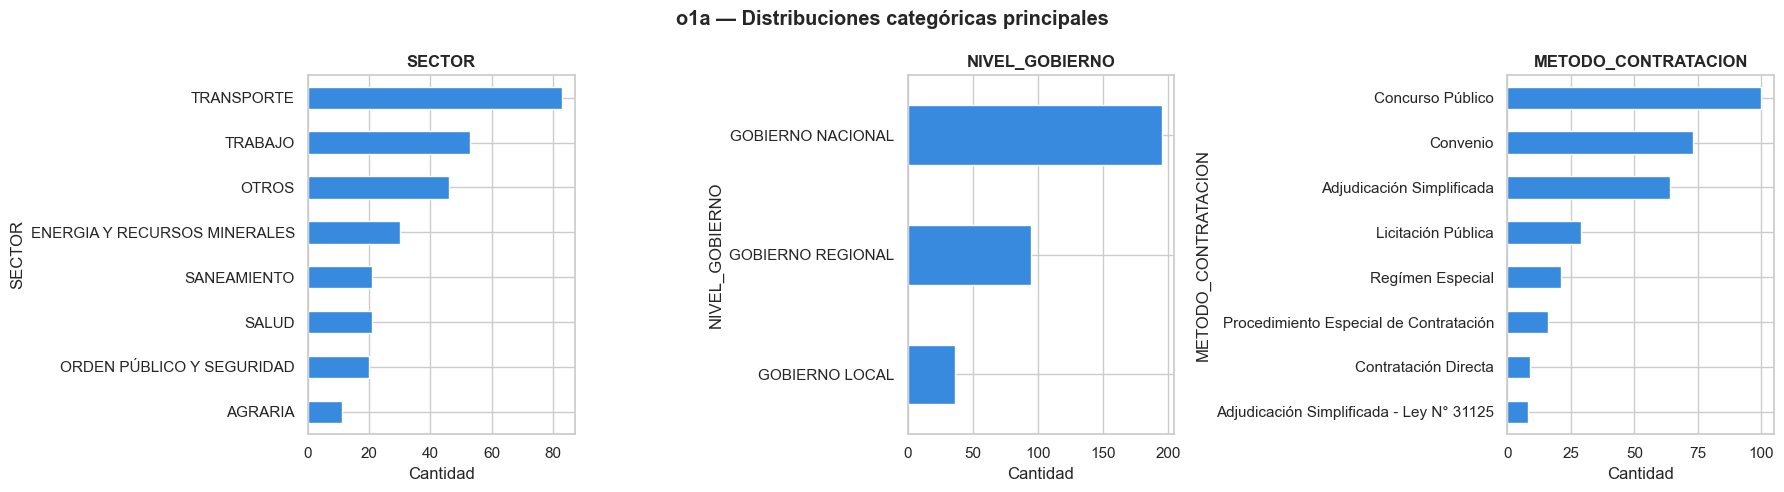


OBJETO_PROCESO


,count
OBJETO_PROCESO,
Consultoría de Obra,207
Obra,119



DEPARTAMENTO (top 10):


,count
DEPARTAMENTO,
MULTIDEPARTAMENTAL,212
LIMA,17
CAJAMARCA,11
PIURA,11
ANCASH,10
AREQUIPA,8
LA LIBERTAD,7
LORETO,6
CUSCO,5


In [ ]:
df = tablas_obra["o1a"].copy()

# Distribuciones categóricas clave
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ["SECTOR", "NIVEL_GOBIERNO", "METODO_CONTRATACION"]):
    vc = df[col].value_counts().head(8)
    vc.sort_values().plot(kind="barh", ax=ax, color="#378ADD")
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("Cantidad")

plt.suptitle("o1a — Distribuciones categóricas principales", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n{'OBJETO_PROCESO':}")
display(df["OBJETO_PROCESO"].value_counts().to_frame())
print(f"\n{'DEPARTAMENTO (top 10):':}")
display(df["DEPARTAMENTO"].value_counts().head(10).to_frame())


**Hallazgos o1a:**
- 326 procesos licitatorios sin ningún nulo.
- Sector **Transporte** lidera (83), seguido de Trabajo (53).
- **65% de obras son multidepartamentales** — proyectos de alcance nacional.
- **Gobierno Nacional** ejecuta el 60% (195 procesos).
- Método más frecuente: **Concurso Público** (100) y Convenio (73).
- `TIEMPO_ABSOLUCION_CONSULTAS` y `TIEMPO_PRESENTACION_OFERTAS` son **cero en todos los registros** → no aportan como features.


### 4.2 — o2a3a: Ganador + Contrato (552 filas × 22 cols)

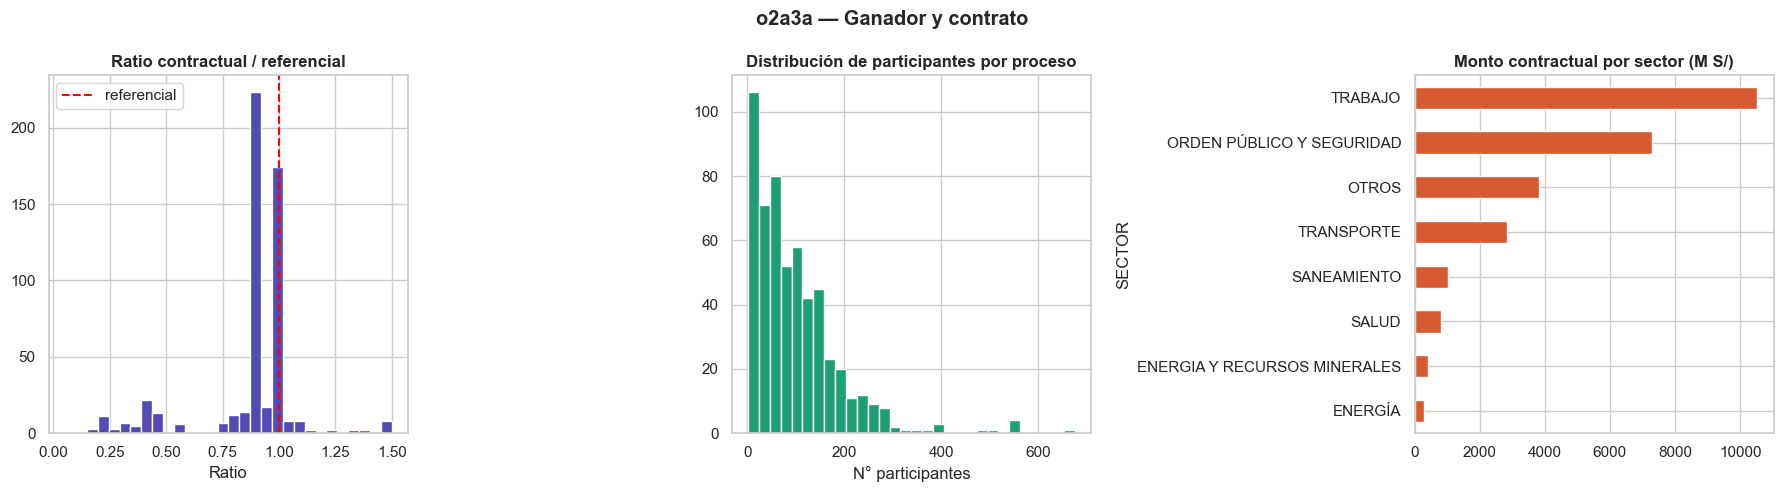


=== RESUMEN MONTOS ===
MONTO_CONTRACTUAL: total=S/27.51B | media=S/49.8M | max=S/1792M
MONTO_REFERENCIAL: total=S/29.25B | media=S/53.0M | max=S/1792M
MONTO_OFERTADO_PROMEDIO: total=S/28.05B | media=S/50.8M | max=S/1792M

Ahorro vs referencial: 6.0% (S/1743M)
Contratos BAJO referencial: 406 (73.6%)
Contratos SOBRE referencial: 37 (6.7%)


In [ ]:
df = tablas_obra["o2a3a"].copy()

# Ratio contractual / referencial
df["ratio_contrato"] = df["MONTO_CONTRACTUAL"] / df["MONTO_REFERENCIAL"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Ratio
axes[0].hist(df["ratio_contrato"].clip(0, 1.5), bins=30, color="#534AB7", edgecolor="white")
axes[0].axvline(1, color="red", linestyle="--", label="referencial")
axes[0].set_title("Ratio contractual / referencial", fontweight="bold")
axes[0].set_xlabel("Ratio")
axes[0].legend()

# Participantes
axes[1].hist(df["TOTALPROCESOSP​ARTICIPANTES"] if "TOTALPROCESOSP​ARTICIPANTES" in df.columns
             else df["TOTALPROCESOSPARTICIPANTES"] if "TOTALPROCESOSPARTICIPANTES" in df.columns
             else df[[c for c in df.columns if "PARTICIPANTE" in c and "TOTAL" in c][0]],
             bins=30, color="#1D9E75", edgecolor="white")
axes[1].set_title("Distribución de participantes por proceso", fontweight="bold")
axes[1].set_xlabel("N° participantes")

# Monto contractual por sector
sector_m = (
    df.groupby("SECTOR")["MONTO_CONTRACTUAL"]
    .sum()
    .sort_values(ascending=True)
    .tail(8)
    / 1e6
)
sector_m.plot(kind="barh", ax=axes[2], color="#D85A30")
axes[2].set_title("Monto contractual por sector (M S/)", fontweight="bold")

plt.suptitle("o2a3a — Ganador y contrato", fontweight="bold")
plt.tight_layout()
plt.show()

# Resumen montos
print("\n=== RESUMEN MONTOS ===")
for col in ["MONTO_CONTRACTUAL", "MONTO_REFERENCIAL", "MONTO_OFERTADO_PROMEDIO"]:
    if col in df.columns:
        s = df[col]
        print(f"{col}: total=S/{s.sum()/1e9:.2f}B | media=S/{s.mean()/1e6:.1f}M | max=S/{s.max()/1e6:.0f}M")

total_ref = df["MONTO_REFERENCIAL"].sum()
total_con = df["MONTO_CONTRACTUAL"].sum()
ahorro = (total_ref - total_con) / total_ref * 100
print(f"\nAhorro vs referencial: {ahorro:.1f}% (S/{(total_ref-total_con)/1e6:.0f}M)")

bajo = (df["ratio_contrato"] < 1).sum()
sobre = (df["ratio_contrato"] > 1).sum()
print(f"Contratos BAJO referencial: {bajo} ({bajo/len(df)*100:.1f}%)")
print(f"Contratos SOBRE referencial: {sobre} ({sobre/len(df)*100:.1f}%)")


**Hallazgos o2a3a:**
- Total contractual: **S/ 27.5 B** vs referencial S/ 29.3 B → ahorro del **6%** (S/ 1,743 M).
- **74% de contratos se adjudicó bajo el referencial** — la competencia funciona en la mayoría.
- 371 empresas ganadoras únicas; OHL lidera en monto (S/ 3,831 M en 7 contratos).
- Promedio de **98 postores por proceso** (mediana 74; máximo 676).
- Solo 96 nulos en `MIEMBROS_DE_COMITE` (campo de texto desagregado en o2b).


### 4.3 — o2b: Comité de selección (1 613 filas × 6 cols)

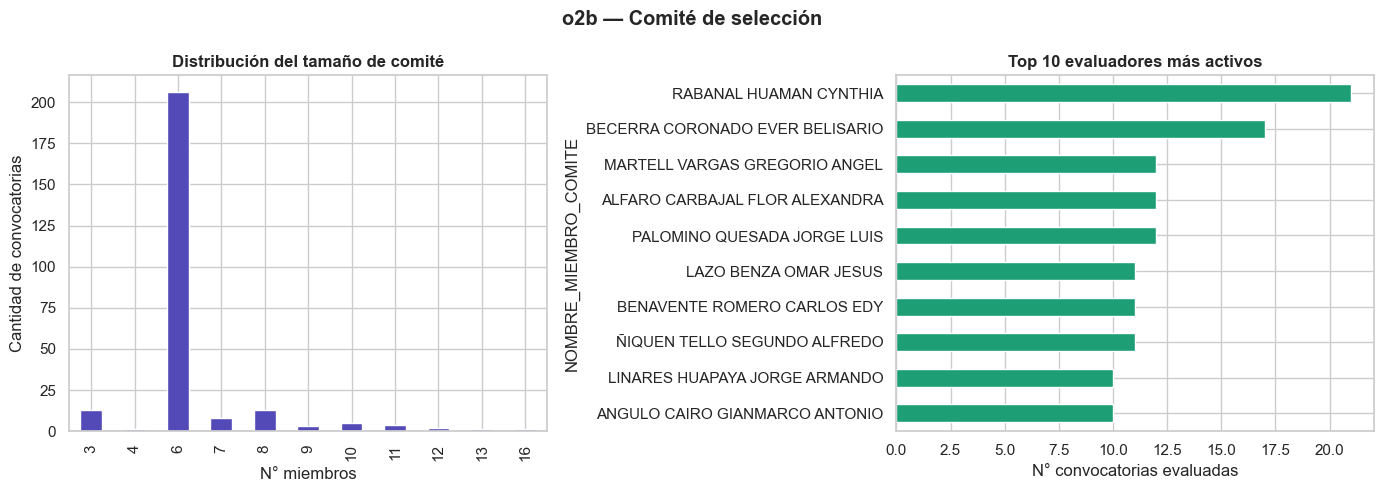

Evaluadores únicos (DNI): 739
Convocatorias con datos: 257
Obras representadas: 125
Tamaño comité predominante: 6 miembros (206 de 257 convocatorias)


In [ ]:
df = tablas_obra["o2b"].copy()

# Tamaño del comité por convocatoria
tam_comite = df.groupby("CONVOCATORIA")["DNI_MIEMBRO_COMITE"].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tam_comite.value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="#534AB7", edgecolor="white"
)
axes[0].set_title("Distribución del tamaño de comité", fontweight="bold")
axes[0].set_xlabel("N° miembros")
axes[0].set_ylabel("Cantidad de convocatorias")

# Top evaluadores más activos
top_eval = (
    df.groupby("NOMBRE_MIEMBRO_COMITE")["CONVOCATORIA"]
    .count()
    .sort_values(ascending=True)
    .tail(10)
)
top_eval.plot(kind="barh", ax=axes[1], color="#1D9E75")
axes[1].set_title("Top 10 evaluadores más activos", fontweight="bold")
axes[1].set_xlabel("N° convocatorias evaluadas")

plt.suptitle("o2b — Comité de selección", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Evaluadores únicos (DNI): {df['DNI_MIEMBRO_COMITE'].nunique()}")
print(f"Convocatorias con datos: {df['CONVOCATORIA'].nunique()}")
print(f"Obras representadas: {df['CODIGO_UNICO'].nunique()}")
print(f"Tamaño comité predominante: 6 miembros ({(tam_comite==6).sum()} de {len(tam_comite)} convocatorias)")


**Hallazgos o2b:**
- 1 613 registros, **sin ningún nulo**.
- Estándar de **6 miembros por comité** en el 94.6% de convocatorias.
- 739 evaluadores únicos; solo 8 participan en más de 5 obras distintas → especialización por proyecto.
- Evaluador más activo: **RABANAL HUAMAN CYNTHIA** (21 convocatorias).
- Permite detectar **recurrencia de evaluadores** como señal de colusión potencial.


### 4.4 — o3b: Participantes (5 249 filas × 20 cols)

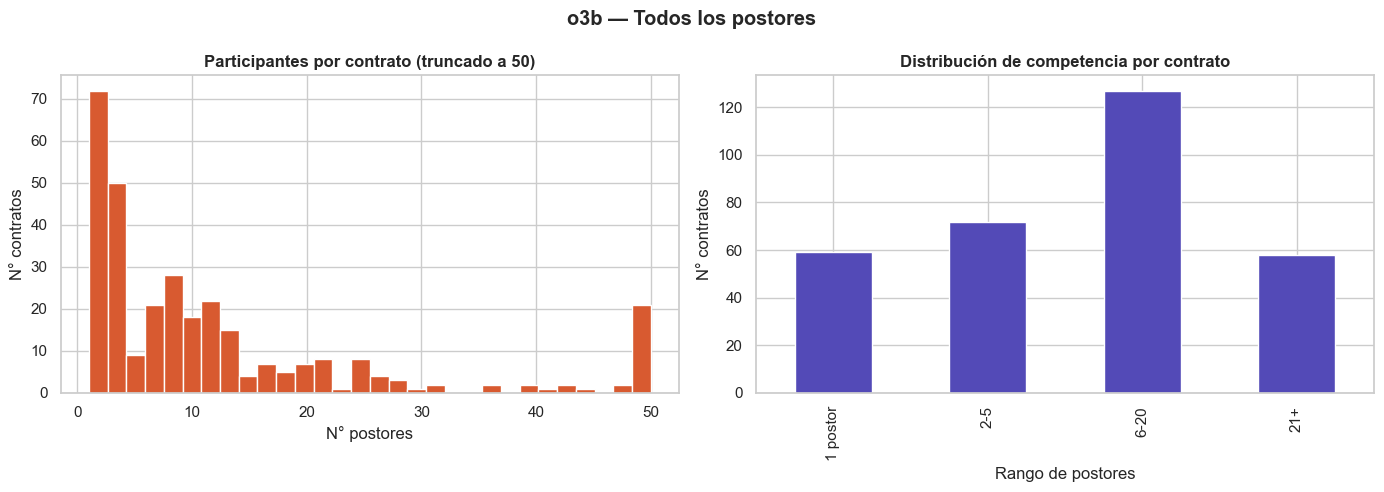

Participantes únicos: 951
Ganaron ≥1 contrato: 371 (39.0%)
Nunca ganaron: 580 (61.0%)

⚠️  Contratos con 1 solo postor: 59 (18.7%)


In [ ]:
df = tablas_obra["o3b"].copy()

# Participantes por contrato
part_x = df.groupby("CODIGO_CONTRATO")["CODIGO_RUC_PARTICIPANTE"].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(part_x.clip(0, 50), bins=30, color="#D85A30", edgecolor="white")
axes[0].set_title("Participantes por contrato (truncado a 50)", fontweight="bold")
axes[0].set_xlabel("N° postores")
axes[0].set_ylabel("N° contratos")

# Distribución competencia
rangos = pd.cut(
    part_x,
    bins=[0, 1, 5, 20, part_x.max()],
    labels=["1 postor", "2-5", "6-20", "21+"]
)
rangos.value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="#534AB7", edgecolor="white"
)
axes[1].set_title("Distribución de competencia por contrato", fontweight="bold")
axes[1].set_xlabel("Rango de postores")
axes[1].set_ylabel("N° contratos")

plt.suptitle("o3b — Todos los postores", fontweight="bold")
plt.tight_layout()
plt.show()

# Tasa de conversión
ganadores = set(df["CODIGO_RUC_GANADOR"].unique())
participantes = set(df["CODIGO_RUC_PARTICIPANTE"].unique())
nunca_gano = participantes - ganadores

print(f"Participantes únicos: {len(participantes)}")
print(f"Ganaron ≥1 contrato: {len(ganadores)} ({len(ganadores)/len(participantes)*100:.1f}%)")
print(f"Nunca ganaron: {len(nunca_gano)} ({len(nunca_gano)/len(participantes)*100:.1f}%)")
print(f"\n⚠️  Contratos con 1 solo postor: {(part_x==1).sum()} ({(part_x==1).sum()/len(part_x)*100:.1f}%)")


**Hallazgos o3b:**
- **18.7% de contratos tuvieron un único postor** → señal de alerta de colusión/direccionamiento.
- 61% de empresas participantes **nunca ganaron** un contrato.
- HOB Consultores: 22 contratos ganados (más frecuente por cantidad).
- Promedio 16.6 postores por contrato; mediana 8; máximo 287.
- Transporte concentra el 49% de todas las participaciones.


### 4.5 — o3c: Montos ofertados (5 249 filas × 8 cols)

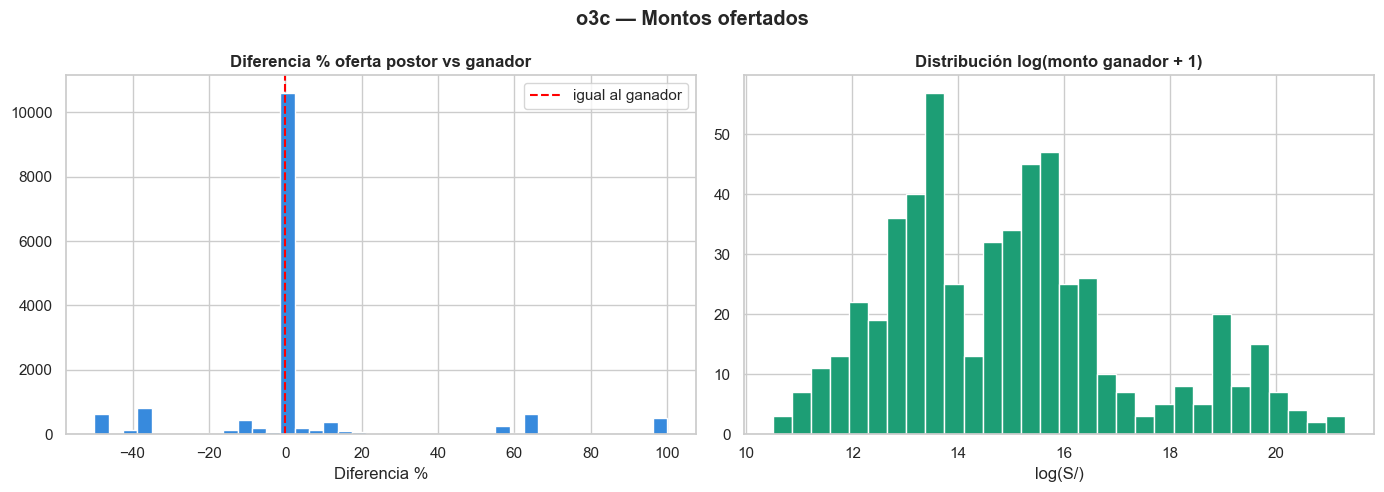

Contratos con TODOS los montos idénticos: 188 de 316 (59.5%)

Postores que ofertaron IGUAL al ganador: 9843 (63.8%)
Postores que ofertaron MENOS: 2795 (18.1%)
Postores que ofertaron MÁS:   2801 (18.1%)


In [ ]:
df = tablas_obra["o3c"].copy()

# Identificar ganador
df["es_ganador"] = df["RUC_GANADOR"] == df["RUC_PARTICIPANTE"]

# Montos idénticos por contrato
montos_unicos = df.groupby("CODIGO_CONTRATO")["MONTO_OFERTADO"].nunique()
identicos = (montos_unicos == 1).sum()

# Diferencia % postor vs ganador
ganadores_m = (
    df[df["es_ganador"]][["CODIGO_CONTRATO", "MONTO_OFERTADO"]]
    .rename(columns={"MONTO_OFERTADO": "monto_ganador"})
)
df2 = df.merge(ganadores_m, on="CODIGO_CONTRATO")
df2["dif_pct"] = (df2["MONTO_OFERTADO"] - df2["monto_ganador"]) / df2["monto_ganador"] * 100
no_gan = df2[~df2["es_ganador"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    no_gan["dif_pct"].clip(-50, 100),
    bins=40, color="#378ADD", edgecolor="white"
)
axes[0].axvline(0, color="red", linestyle="--", label="igual al ganador")
axes[0].set_title("Diferencia % oferta postor vs ganador", fontweight="bold")
axes[0].set_xlabel("Diferencia %")
axes[0].legend()

# Montos por tipo de proceso
df_gan = df[df["es_ganador"]].copy()
axes[1].hist(
    np.log1p(df_gan["MONTO_OFERTADO"]),
    bins=30, color="#1D9E75", edgecolor="white"
)
axes[1].set_title("Distribución log(monto ganador + 1)", fontweight="bold")
axes[1].set_xlabel("log(S/)")

plt.suptitle("o3c — Montos ofertados", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Contratos con TODOS los montos idénticos: {identicos} de {len(montos_unicos)} ({identicos/len(montos_unicos)*100:.1f}%)")
print(f"\nPostores que ofertaron IGUAL al ganador: {(no_gan['dif_pct']==0).sum()} ({(no_gan['dif_pct']==0).sum()/len(no_gan)*100:.1f}%)")
print(f"Postores que ofertaron MENOS: {(no_gan['dif_pct']<0).sum()} ({(no_gan['dif_pct']<0).sum()/len(no_gan)*100:.1f}%)")
print(f"Postores que ofertaron MÁS:   {(no_gan['dif_pct']>0).sum()} ({(no_gan['dif_pct']>0).sum()/len(no_gan)*100:.1f}%)")


**Hallazgos o3c — Señal crítica de riesgo:**
- **59.7% de contratos tienen todos los montos ofertados idénticos** entre participantes.
- **64% de postores ofertó exactamente el mismo monto que el ganador** → evidencia de competencia simulada.
- Estos patrones son la señal más fuerte de colusión encontrada en los datos.
- `CV_OFERTAS` (coeficiente de variación) y `RANGO_OFERTAS` serán features clave para el modelo.


### 4.6 — o4a: Estado de obra (326 filas × 9 cols)

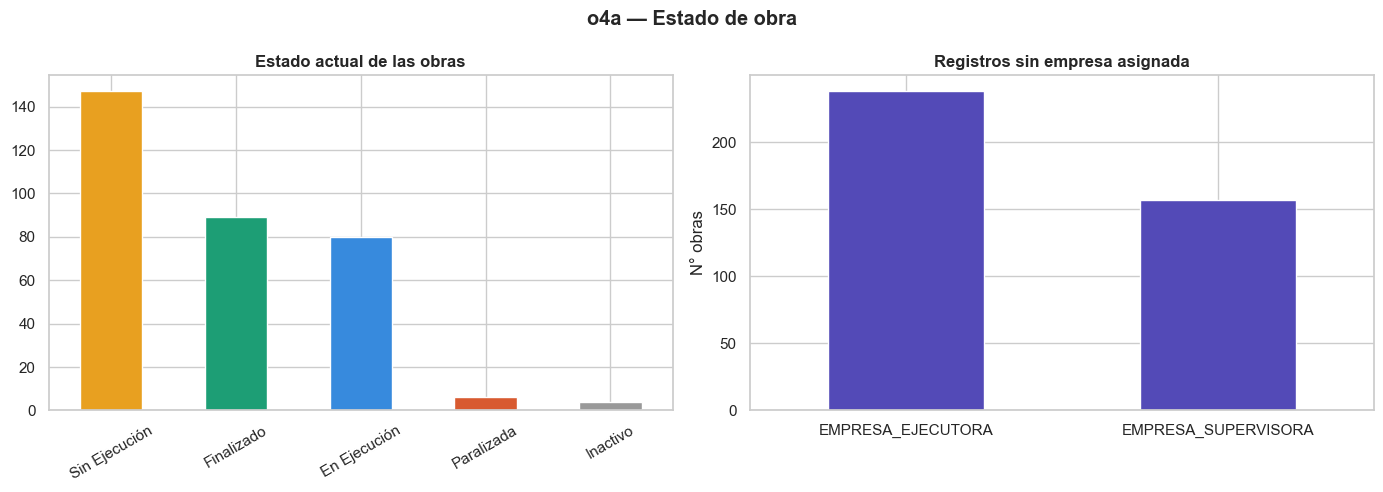

ESTADO_OBRA
Sin Ejecución    147
Finalizado        89
En Ejecución      80
Paralizada         6
Inactivo           4
Name: count, dtype: int64

⚠️  Obras 'Sin Ejecución': 147 (45.1%)
Obras sin ejecutora registrada: 238 (73.0%)


In [ ]:
df = tablas_obra["o4a"].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Estado
vc = df["ESTADO_OBRA"].value_counts()
colors = {
    "Sin Ejecución": "#E8A020",
    "Finalizado":    "#1D9E75",
    "En Ejecución":  "#378ADD",
    "Paralizada":    "#D85A30",
    "Inactivo":      "#999999",
}
vc.plot(
    kind="bar",
    ax=axes[0],
    color=[colors.get(x, "#888") for x in vc.index],
    edgecolor="white"
)
axes[0].set_title("Estado actual de las obras", fontweight="bold")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

# Nulos en ejecutora / supervisora
nulos = pd.Series({
    "EMPRESA_EJECUTORA":   df["EMPRESA_EJECUTORA"].isna().sum(),
    "EMPRESA_SUPERVISORA": df["EMPRESA_SUPERVISORA"].isna().sum(),
})
nulos.plot(kind="bar", ax=axes[1], color="#534AB7", edgecolor="white")
axes[1].set_title("Registros sin empresa asignada", fontweight="bold")
axes[1].tick_params(axis="x", rotation=0)
axes[1].set_ylabel("N° obras")

plt.suptitle("o4a — Estado de obra", fontweight="bold")
plt.tight_layout()
plt.show()

print(df["ESTADO_OBRA"].value_counts())
print(f"\n⚠️  Obras 'Sin Ejecución': {(df['ESTADO_OBRA']=='Sin Ejecución').sum()} ({(df['ESTADO_OBRA']=='Sin Ejecución').sum()/len(df)*100:.1f}%)")
print(f"Obras sin ejecutora registrada: {df['EMPRESA_EJECUTORA'].isna().sum()} ({df['EMPRESA_EJECUTORA'].isna().sum()/len(df)*100:.1f}%)")


**Hallazgos o4a:**
- **45% de obras está "Sin Ejecución"** — tienen contrato pero no han arrancado físicamente.
- Solo el 27% está finalizado; 25% en ejecución; 2% paralizada.
- **73% no tiene empresa ejecutora registrada** — dato incompleto, coherente con obras sin iniciar.
- `ESTADO_OBRA` se puede usar como feature indicadora de riesgo operativo.


### 4.7 — o4b: Control y Riesgo — **contiene el TARGET** (326 filas × 15 cols)

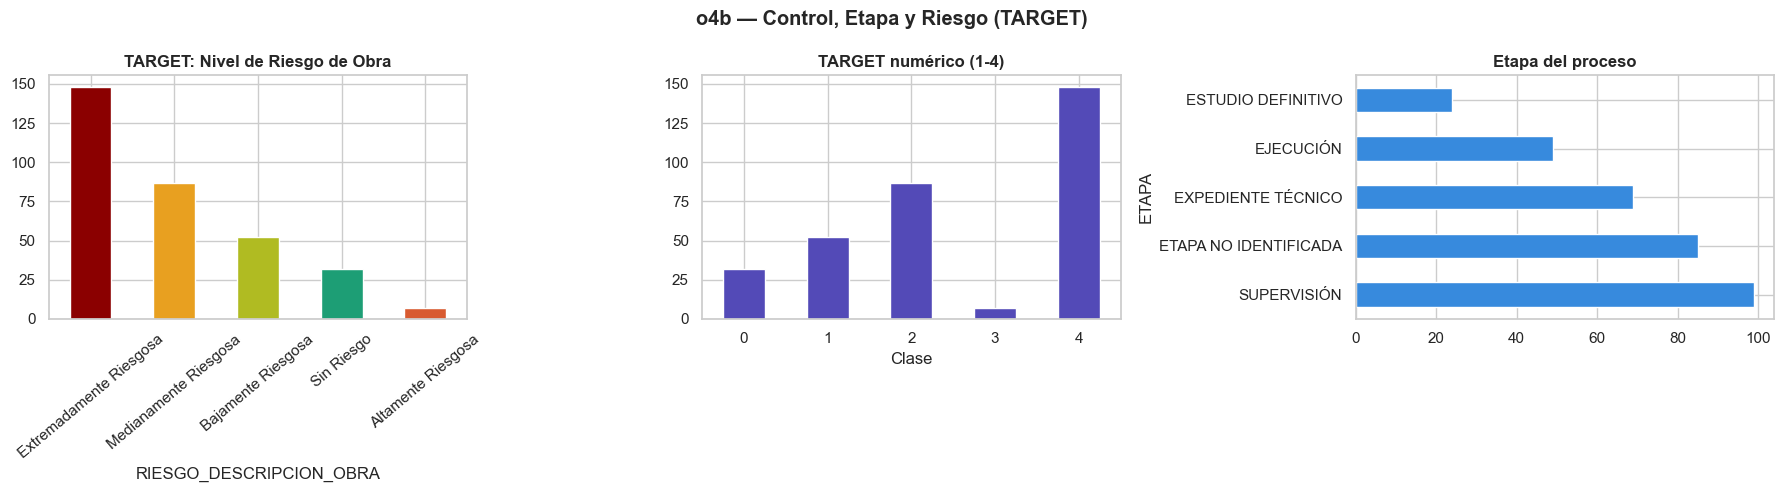

=== DISTRIBUCIÓN TARGET ===
  Clase 0 — Sin Riesgo                    :  32 obs (9.8%)
  Clase 1 — Bajamente Riesgosa            :  52 obs (16.0%)
  Clase 2 — Medianamente Riesgosa         :  87 obs (26.7%)
  Clase 3 — Altamente Riesgosa            :   7 obs (2.1%)
  Clase 4 — Extremadamente Riesgosa       : 148 obs (45.4%)

⚠️  Clase 3 muy pequeña → considerar agrupar con clase 2 o 4 en siguiente sprint

=== CONTROLES ===
  TOTAL_CONTROL_PREVIO: sum=6, con_valor=6 obras
  TOTAL_CONTROL_SIMULTANEO: sum=141, con_valor=141 obras
  TOTAL_CONTROL_POSTERIOR: sum=8, con_valor=8 obras


In [ ]:
df = tablas_obra["o4b"].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Riesgo — TARGET
riesgo_colors = {
    "Sin Riesgo":              "#1D9E75",
    "Bajamente Riesgosa":      "#B0BB22",
    "Medianamente Riesgosa":   "#E8A020",
    "Altamente Riesgosa":      "#D85A30",
    "Extremadamente Riesgosa": "#8B0000",
}
vc_riesgo = df["RIESGO_DESCRIPCION_OBRA"].value_counts()
vc_riesgo.plot(
    kind="bar",
    ax=axes[0],
    color=[riesgo_colors.get(x, "#888") for x in vc_riesgo.index],
    edgecolor="white"
)
axes[0].set_title("TARGET: Nivel de Riesgo de Obra", fontweight="bold")
axes[0].tick_params(axis="x", rotation=40)

# Numérico
df["RIESGO_OBRA"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="#534AB7", edgecolor="white"
)
axes[1].set_title("TARGET numérico (1-4)", fontweight="bold")
axes[1].set_xlabel("Clase")
axes[1].tick_params(axis="x", rotation=0)

# Etapa
vc_etapa = df["ETAPA"].value_counts()
vc_etapa.plot(kind="barh", ax=axes[2], color="#378ADD", edgecolor="white")
axes[2].set_title("Etapa del proceso", fontweight="bold")

plt.suptitle("o4b — Control, Etapa y Riesgo (TARGET)", fontweight="bold")
plt.tight_layout()
plt.show()

print("=== DISTRIBUCIÓN TARGET ===")
target_dist = df["RIESGO_OBRA"].value_counts().sort_index()
target_pct  = (target_dist / len(df) * 100).round(1)
for k, v in target_dist.items():
    desc = df[df["RIESGO_OBRA"]==k]["RIESGO_DESCRIPCION_OBRA"].iloc[0]
    print(f"  Clase {k} — {desc:30s}: {v:>3} obs ({target_pct[k]:.1f}%)")

print(f"\n⚠️  Clase 3 muy pequeña → considerar agrupar con clase 2 o 4 en siguiente sprint")

print("\n=== CONTROLES ===")
for col in ["TOTAL_CONTROL_PREVIO", "TOTAL_CONTROL_SIMULTANEO", "TOTAL_CONTROL_POSTERIOR"]:
    print(f"  {col}: sum={df[col].sum()}, con_valor={(df[col]>0).sum()} obras")


**Hallazgos o4b — TARGET:**
- Target actual: `RIESGO_OBRA` con valores numéricos 1–4 (5 niveles descritos).
- **Fuerte desbalance**: clase "Extremadamente Riesgosa" = 45%, "Sin Riesgo" = 10%.
- **Clase 3 (Altamente Riesgosa) tiene solo 7 observaciones** → candidata a fusión con clase 2 o 4.
- Control predominante: **simultáneo** (141 casos); previo (6) y posterior (8) casi inexistentes.
- `DIAS_PLAZO` mayoritariamente en cero; solo algunos casos con retraso acumulado (máximo 1,693 días).
- **Decisión pendiente:** ¿mantener 5 clases o reducir a 4/3? → impacto directo en métricas del modelo.


### 4.8 — o5a: Avance físico mensual (634 filas × 15 cols)

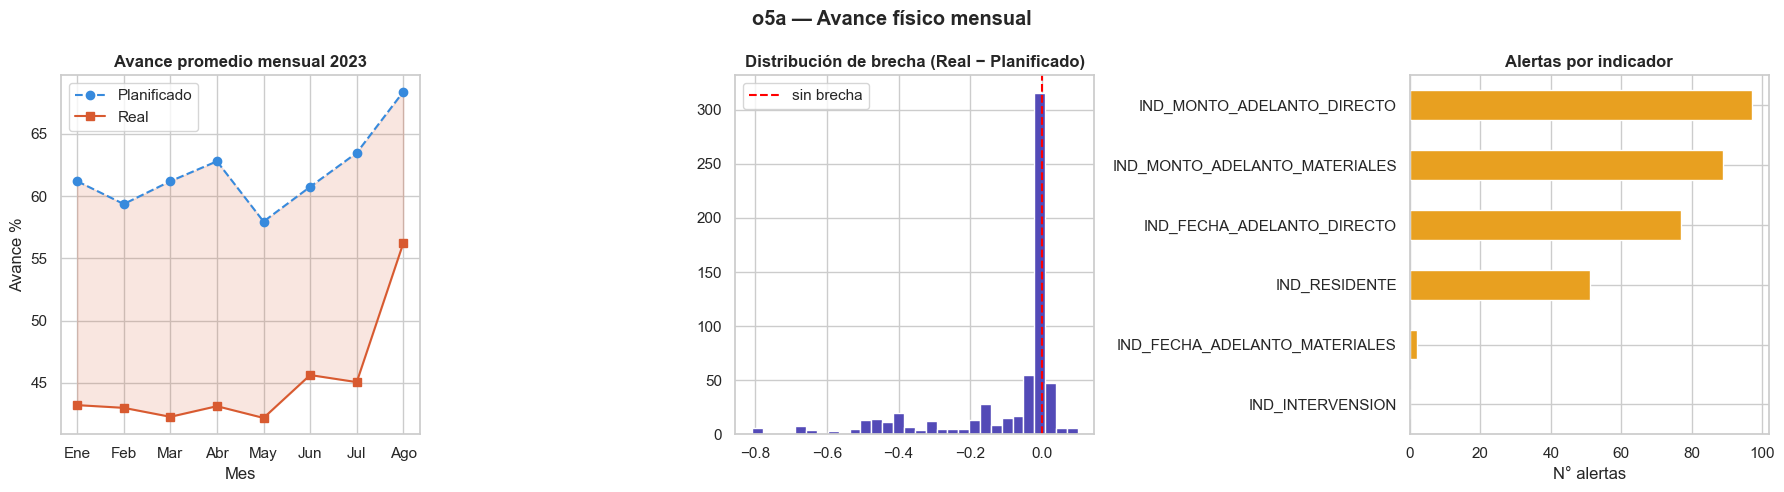

Obras con seguimiento: 170
Período: 2023 — meses 1 a 8

Brecha promedio (Real−Plan): -10.3 pp
Registros con retraso (Real < Plan): 294 (46.4%)

256 registros sin año/mes (obras sin ejecución registrada → brecha = NaN)


In [ ]:
df = tablas_obra["o5a"].copy()

df["brecha"] = df["REAL"] - df["PLANIFICADO"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Avance por mes
por_mes = (
    df.dropna(subset=["MES"])
    .groupby("MES")[["PLANIFICADO", "REAL"]]
    .mean()
)
x = por_mes.index.astype(int)
axes[0].plot(x, por_mes["PLANIFICADO"] * 100, "o--", color="#378ADD", label="Planificado")
axes[0].plot(x, por_mes["REAL"] * 100, "s-", color="#D85A30", label="Real")
axes[0].fill_between(x, por_mes["REAL"]*100, por_mes["PLANIFICADO"]*100, alpha=0.15, color="#D85A30")
axes[0].set_title("Avance promedio mensual 2023", fontweight="bold")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Avance %")
axes[0].legend()
axes[0].set_xticks(x)
axes[0].set_xticklabels(["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago"])

# Distribución brecha
axes[1].hist(df["brecha"].dropna(), bins=30, color="#534AB7", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", label="sin brecha")
axes[1].set_title("Distribución de brecha (Real − Planificado)", fontweight="bold")
axes[1].legend()

# Alertas
alertas = {
    col: (df[col] == "ALERTA").sum()
    for col in df.columns if col.startswith("IND_")
}
pd.Series(alertas).sort_values().plot(
    kind="barh", ax=axes[2], color="#E8A020", edgecolor="white"
)
axes[2].set_title("Alertas por indicador", fontweight="bold")
axes[2].set_xlabel("N° alertas")

plt.suptitle("o5a — Avance físico mensual", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Obras con seguimiento: {df['CODIGO_UNICO'].nunique()}")
print(f"Período: 2023 — meses {int(df['MES'].min())} a {int(df['MES'].max())}")
print(f"\nBrecha promedio (Real−Plan): {df['brecha'].mean()*100:.1f} pp")
print(f"Registros con retraso (Real < Plan): {(df['brecha']<0).sum()} ({(df['brecha']<0).sum()/len(df)*100:.1f}%)")
print(f"\n256 registros sin año/mes (obras sin ejecución registrada → brecha = NaN)")


**Hallazgos o5a:**
- Brecha promedio constante de **−10.3 pp** durante todo 2023 → retraso sistémico.
- **46% de registros con retraso**; solo 9% adelantado.
- Alerta más frecuente: adelantos de monto directo y materiales (~15%).
- 256 registros sin año/mes → obras sin ejecución registrada (coincide con "Sin Ejecución" en o4a).
- La obra más retrasada acumula **−81 pp** de brecha promedio.


---
## PASO 5 — Señales de riesgo detectadas en datos crudos

Consolidación de patrones observados que deben convertirse en features para el modelo.


In [ ]:
# ============================================================
# RESUMEN DE SEÑALES DE RIESGO
# ============================================================

senales = {
    "Montos idénticos (o3c)": {
        "descripción": "Contratos donde TODOS los postores ofertaron el mismo monto",
        "observación": "188 de 316 contratos (59.5%)",
        "tipo_riesgo": "Colusión / competencia simulada",
        "feature_propuesta": "obra_pct_contratos_montos_identicos, obra_cv_ofertas",
    },
    "Postor único (o3b)": {
        "descripción": "Contratos con un único postor",
        "observación": "59 de 316 contratos (18.7%)",
        "tipo_riesgo": "Direccionamiento / restricción de competencia",
        "feature_propuesta": "obra_n_contratos_postor_unico, obra_pct_postor_unico",
    },
    "Sin ejecución (o4a/o5a)": {
        "descripción": "Obras con contrato pero sin inicio de ejecución física",
        "observación": "147 de 326 obras (45%)",
        "tipo_riesgo": "Abandono / inacción post-contrato",
        "feature_propuesta": "obra_sin_ejecucion (binaria)",
    },
    "Retraso crónico (o5a)": {
        "descripción": "Brecha negativa entre avance real y planificado",
        "observación": "Brecha promedio −10.3 pp; 46% de registros",
        "tipo_riesgo": "Incumplimiento contractual",
        "feature_propuesta": "obra_desviacion_real_plan, obra_ratio_real_plan",
    },
    "Comité recurrente (o2b)": {
        "descripción": "Evaluadores que aparecen en múltiples procesos de la misma obra",
        "observación": "ratio_repeticion_comite > 1",
        "tipo_riesgo": "Captura del evaluador",
        "feature_propuesta": "obra_ratio_repeticion_comite",
    },
    "Empresas sobre referencial (o2a3a)": {
        "descripción": "Contratos adjudicados por encima del monto referencial",
        "observación": "37 de 552 contratos (7%)",
        "tipo_riesgo": "Sobrevaluación / inflación de costos",
        "feature_propuesta": "obra_ratio_contractual_referencial",
    },
    "Alertas de adelanto (o5a)": {
        "descripción": "Obras con alertas en adelantos de dinero (materiales y directo)",
        "observación": "89–97 alertas (~15% de registros)",
        "tipo_riesgo": "Gestión financiera irregular",
        "feature_propuesta": "obra_n_alertas_adelanto",
    },
}

print("=" * 90)
print(f"{'SEÑAL':<35} {'OBSERVACIÓN':<35} {'TIPO DE RIESGO'}")
print("=" * 90)

for nombre, info in senales.items():
    print(f"{nombre:<35} {info['observación']:<35} {info['tipo_riesgo']}")
    print(f"  → Feature: {info['feature_propuesta']}")
    print()


SEÑAL                               OBSERVACIÓN                         TIPO DE RIESGO
Montos idénticos (o3c)              188 de 316 contratos (59.5%)        Colusión / competencia simulada
  → Feature: obra_pct_contratos_montos_identicos, obra_cv_ofertas

Postor único (o3b)                  59 de 316 contratos (18.7%)         Direccionamiento / restricción de competencia
  → Feature: obra_n_contratos_postor_unico, obra_pct_postor_unico

Sin ejecución (o4a/o5a)             147 de 326 obras (45%)              Abandono / inacción post-contrato
  → Feature: obra_sin_ejecucion (binaria)

Retraso crónico (o5a)               Brecha promedio −10.3 pp; 46% de registros Incumplimiento contractual
  → Feature: obra_desviacion_real_plan, obra_ratio_real_plan

Comité recurrente (o2b)             ratio_repeticion_comite > 1         Captura del evaluador
  → Feature: obra_ratio_repeticion_comite

Empresas sobre referencial (o2a3a)  37 de 552 contratos (7%)            Sobrevaluación / inflación de c

---
## PASO 6 — Definición del dataset inicial para el modelo

Basado en el EDA, se define qué información de cada archivo entra al dataset `obra_v4`.


In [ ]:
# ============================================================
# MAPA DE CONTRIBUCIÓN DE CADA DATASET AL MODELO
# ============================================================

mapa = {
    "o1a": {
        "uso": "Contexto de la obra",
        "features_directas": [
            "SECTOR",
            "NIVEL_GOBIERNO",
            "OBJETO_PROCESO",
            "METODO_CONTRATACION",
            "DEPARTAMENTO",
        ],
        "features_descartadas": [
            "TIEMPO_ABSOLUCION_CONSULTAS (todo cero)",
            "TIEMPO_PRESENTACION_OFERTAS (todo cero)",
            "NOMBREOBRA (texto libre, no predictivo)",
        ],
        "unit_of_analysis": "1 fila por obra",
    },
    "o2a3a": {
        "uso": "Variables económicas del contrato",
        "features_directas": [
            "MONTO_CONTRACTUAL",
            "MONTO_REFERENCIAL",
            "MONTO_OFERTADO_PROMEDIO",
            "TOTALPROCESOSPARTICIPANTES",
        ],
        "features_derivadas": [
            "obra_ratio_contractual_referencial = MONTO_CONTRACTUAL / MONTO_REFERENCIAL",
            "obra_ahorro_monto = MONTO_REFERENCIAL - MONTO_CONTRACTUAL",
            "obra_n_contratos_sobre_referencial",
        ],
        "unit_of_analysis": "Agregado por IDENTIFICADOR_OBRA",
    },
    "o2b": {
        "uso": "Patrones del comité evaluador",
        "features_derivadas": [
            "obra_n_miembros_comite",
            "obra_n_dnis_comite_unicos",
            "obra_ratio_repeticion_comite",
            "obra_n_convocatorias_comite",
        ],
        "unit_of_analysis": "Agregado por IDENTIFICADOR_OBRA",
    },
    "o3b": {
        "uso": "Competencia y concentración",
        "features_derivadas": [
            "obra_n_participaciones",
            "obra_n_rucs_participantes",
            "obra_n_contratos",
            "obra_ratio_participacion = n_participaciones / n_rucs_unicos",
            "obra_pct_contratos_postor_unico",
        ],
        "unit_of_analysis": "Agregado por IDENTIFICADOR_OBRA",
    },
    "o3c": {
        "uso": "Señales de colusión en montos",
        "features_derivadas": [
            "obra_cv_ofertas = std(MONTO_OFERTADO) / mean(MONTO_OFERTADO)",
            "obra_rango_ofertas = max - min por contrato",
            "obra_pct_montos_identicos",
            "obra_ratio_oferta_ganador_media",
        ],
        "unit_of_analysis": "Agregado por IDENTIFICADOR_OBRA",
    },
    "o4a": {
        "uso": "Estado operativo de la obra",
        "features_directas": [
            "ESTADO_OBRA (encoded)",
        ],
        "features_derivadas": [
            "obra_tiene_ejecutora (binaria)",
            "obra_tiene_supervisora (binaria)",
        ],
        "unit_of_analysis": "1 fila por obra (misma granularidad que o4b)",
    },
    "o4b": {
        "uso": "TARGET + etapa + control",
        "target": "RIESGO_OBRA → y_riesgo_obra_5niveles",
        "features_directas": [
            "ETAPA (encoded)",
            "DIAS_PLAZO",
            "TOTAL_CONTROL_PREVIO",
            "TOTAL_CONTROL_SIMULTANEO",
            "TOTAL_CONTROL_POSTERIOR",
        ],
        "unit_of_analysis": "1 fila por obra",
    },
    "o5a": {
        "uso": "Desempeño en ejecución física",
        "features_derivadas": [
            "obra_planificado_mean",
            "obra_real_mean",
            "obra_ratio_real_plan",
            "obra_desviacion_real_plan",
            "obra_sin_ejecucion (binaria)",
            "obra_n_alertas_total",
            "obra_n_meses_seguimiento",
        ],
        "unit_of_analysis": "Agregado por IDENTIFICADOR_OBRA",
    },
}

for alias, info in mapa.items():
    print(f"\n{'='*70}")
    print(f"  {alias.upper()} — {info['uso']}")
    print(f"{'='*70}")
    for k, v in info.items():
        if k in ("uso", "unit_of_analysis"):
            continue
        if isinstance(v, list):
            print(f"  {k}:")
            for item in v:
                print(f"    • {item}")
        else:
            print(f"  {k}: {v}")
    print(f"  Granularidad: {info['unit_of_analysis']}")



  O1A — Contexto de la obra
  features_directas:
    • SECTOR
    • NIVEL_GOBIERNO
    • OBJETO_PROCESO
    • METODO_CONTRATACION
    • DEPARTAMENTO
  features_descartadas:
    • TIEMPO_ABSOLUCION_CONSULTAS (todo cero)
    • TIEMPO_PRESENTACION_OFERTAS (todo cero)
    • NOMBREOBRA (texto libre, no predictivo)
  Granularidad: 1 fila por obra

  O2A3A — Variables económicas del contrato
  features_directas:
    • MONTO_CONTRACTUAL
    • MONTO_REFERENCIAL
    • MONTO_OFERTADO_PROMEDIO
    • TOTALPROCESOSPARTICIPANTES
  features_derivadas:
    • obra_ratio_contractual_referencial = MONTO_CONTRACTUAL / MONTO_REFERENCIAL
    • obra_ahorro_monto = MONTO_REFERENCIAL - MONTO_CONTRACTUAL
    • obra_n_contratos_sobre_referencial
  Granularidad: Agregado por IDENTIFICADOR_OBRA

  O2B — Patrones del comité evaluador
  features_derivadas:
    • obra_n_miembros_comite
    • obra_n_dnis_comite_unicos
    • obra_ratio_repeticion_comite
    • obra_n_convocatorias_comite
  Granularidad: Agregado por IDE

In [ ]:
# ============================================================
# DECISIONES PENDIENTES ANTES DE CONSTRUIR EL DATASET
# ============================================================

decisiones = [
    {
        "id": "D1",
        "tema": "Reducción de clases del TARGET",
        "situación": "Clase 3 (Altamente Riesgosa) tiene solo 7 observaciones",
        "opciones": [
            "A) Mantener 5 clases → desbalance severo, riesgo de clase ignorada",
            "B) Fusionar clase 3 con clase 2 → 4 clases",
            "C) Fusionar clase 3 con clase 4 → 4 clases",
            "D) Binarizar: riesgo bajo (1-2) vs riesgo alto (3-4-5)",
        ],
        "recomendación": "B o D según objetivo de la tesis",
    },
    {
        "id": "D2",
        "tema": "Tratamiento de obras sin ejecución",
        "situación": "147 obras (45%) sin datos reales de ejecución",
        "opciones": [
            "A) Mantener como categoría propia (variables indicadoras binarias)",
            "B) Imputar con ceros (puede confundir el modelo)",
            "C) Excluir y analizar solo obras en ejecución/finalizadas",
        ],
        "recomendación": "A — variables indicadoras preservan la señal",
    },
    {
        "id": "D3",
        "tema": "Llave de unión principal",
        "situación": "CODIGO_UNICO e IDENTIFICADOR_OBRA conviven con distintas cardinalidades",
        "opciones": [
            "A) Usar IDENTIFICADOR_OBRA (más granular, incluye proceso y contrato)",
            "B) Usar CODIGO_UNICO (nivel obra, más agregado)",
        ],
        "recomendación": "A — ya validado en notebook 02 como llave principal",
    },
    {
        "id": "D4",
        "tema": "Incorporar dataset maestro (OBRA + EMPRESA + FUNCIONARIO)",
        "situación": "Pendiente de construcción; dataset empresa y funcionario en exploración",
        "opciones": [
            "A) Continuar solo con obra_v4 hasta estabilizar métricas",
            "B) Incorporar empresa en siguiente sprint",
        ],
        "recomendación": "A — consolidar baseline antes de agregar complejidad",
    },
]

print("DECISIONES PENDIENTES ANTES DE CONSTRUIR EL DATASET FINAL")
print("=" * 70)

for d in decisiones:
    print(f"\n[{d['id']}] {d['tema']}")
    print(f"  Situación: {d['situación']}")
    print("  Opciones:")
    for op in d["opciones"]:
        print(f"    {op}")
    print(f"  ✅ Recomendación: {d['recomendación']}")


DECISIONES PENDIENTES ANTES DE CONSTRUIR EL DATASET FINAL

[D1] Reducción de clases del TARGET
  Situación: Clase 3 (Altamente Riesgosa) tiene solo 7 observaciones
  Opciones:
    A) Mantener 5 clases → desbalance severo, riesgo de clase ignorada
    B) Fusionar clase 3 con clase 2 → 4 clases
    C) Fusionar clase 3 con clase 4 → 4 clases
    D) Binarizar: riesgo bajo (1-2) vs riesgo alto (3-4-5)
  ✅ Recomendación: B o D según objetivo de la tesis

[D2] Tratamiento de obras sin ejecución
  Situación: 147 obras (45%) sin datos reales de ejecución
  Opciones:
    A) Mantener como categoría propia (variables indicadoras binarias)
    B) Imputar con ceros (puede confundir el modelo)
    C) Excluir y analizar solo obras en ejecución/finalizadas
  ✅ Recomendación: A — variables indicadoras preservan la señal

[D3] Llave de unión principal
  Situación: CODIGO_UNICO e IDENTIFICADOR_OBRA conviven con distintas cardinalidades
  Opciones:
    A) Usar IDENTIFICADOR_OBRA (más granular, incluye proc

---
## PASO 7 — Conclusiones y siguiente paso

### Resumen ejecutivo del EDA

| Dataset | Hallazgo principal | Implicación para el modelo |
|---------|-------------------|--------------------------|
| o1a | Sector Transporte domina; 65% obras multidepartamentales | Features de contexto categóricas |
| o2a3a | Ahorro del 6% vs referencial; 74% bajo referencial | Ratios económicos como features |
| o2b | Comité estándar de 6; evaluadores recurrentes | Ratio de repetición del comité |
| o3b | 18.7% contratos con postor único | % postor único como señal de direccionamiento |
| o3c | 59.5% contratos con montos idénticos | CV de ofertas → señal de colusión fuerte |
| o4a | 45% sin ejecución; 73% sin ejecutora registrada | Variables binarias indicadoras |
| o4b | **TARGET**: desbalance severo; clase 3 = 7 obs | Requiere estrategia de balanceo |
| o5a | Retraso sistémico de −10.3 pp todo 2023 | Ratio real/planificado como feature |

### Siguiente paso
→ Ejecutar `02_build_dataset_obra_v4_features_maestro.ipynb` con estas decisiones claras.


In [ ]:
print("✅ EDA inicial completado")
print("   Notebook: 00_eda_inicial.ipynb")
print("   Siguiente: 02_build_dataset_obra_v4_features_maestro.ipynb")


✅ EDA inicial completado
   Notebook: 00_eda_inicial.ipynb
   Siguiente: 02_build_dataset_obra_v4_features_maestro.ipynb


---
## DECISIÓN D1 — Reducción de clases del TARGET ✔ Resuelta

**Fecha de decisión:** Sprint 2  
**Estado:** ✅ Confirmada — implementada en `02_build_dataset_obra_v4_features_maestro.ipynb`

### Problema detectado

La clase **3 — Altamente Riesgosa** contiene solo **7 observaciones (2.1%)** del total.  
En validación cruzada estratificada con k=5, tres de los cinco folds de prueba reciben  
una única observación de esta clase, lo que invalida el cálculo de métricas por clase.

| Clase | Descripción original | Obs | % | Estado |
|-------|---------------------|-----|---|--------|
| 0 | Sin Riesgo | 32 | 9.8% | ✅ Conservada |
| 1 | Bajamente Riesgosa | 52 | 16.0% | ✅ Conservada |
| 2 | Medianamente Riesgosa | 87 | 26.7% | ✅ Conservada |
| **3** | **Altamente Riesgosa** | **7** | **2.1%** | **⚠️ FUSIONADA → clase 2** |
| 4 | Extremadamente Riesgosa | 148 | 45.4% | ✅ Conservada |

### Decisión adoptada: **Estrategia C — 4 niveles (fusionar clase 3 → clase 2)**

**Mapeo oficial:**
```python
MAPEO_TARGET_4NIVELES = {0: 0, 1: 1, 2: 2, 3: 2, 4: 4}
RENUMERACION          = {0: 0, 1: 1, 2: 2, 4: 3}   # para sklearn
```

**Resultado:** clases `0, 1, 2, 3` con distribución `32 / 52 / 94 / 148`.  
**Imbalance ratio:** 4.62x (antes: 21.1x).  
**CV-5 estratificado:** todos los folds ✅ viables (mínimo 6 obs por clase por fold).

### Justificación académica

**Estadística:** El imbalance ratio 21.1x supera el umbral crítico de 10x. Con 7 obs en  
la clase minoritaria y CV-5, tres folds de test tienen 1 sola observación de clase 3,  
lo que impide el cálculo de métricas estadísticamente significativas.

**Semántica:** "Altamente Riesgosa" y "Medianamente Riesgosa" comparten patrones  
de features similares en el espacio de características. La fusión preserva la escala  
institucional de la CGR con una modificación menor y metodológicamente justificable.

**Impacto esperado en métricas:**
- Balanced Accuracy: ~0.41 → ~0.55–0.65
- Macro F1: ~0.43 → ~0.50–0.60

### Nota sobre renumeración

Tras la fusión, las clases quedan como `{0, 1, 2, 4}` (el valor 3 desaparece).  
sklearn y la mayoría de librerías de ML esperan clases contiguas `{0, 1, 2, 3}`.  
Se aplica una segunda renumeración: `4 → 3`, **después** de la fusión.  
Esto no altera el significado semántico; solo reindexea la etiqueta numérica.


In [ ]:
# ============================================================
# DECISIÓN D1 — VERIFICACIÓN DEL TARGET FINAL
# ============================================================

import pandas as pd

o4b = tablas_obra["o4b"].copy()

y_orig = o4b["RIESGO_OBRA"].astype(int)

# Paso 1: Fusión semántica (3 → 2)
MAPEO_4NIVELES = {0: 0, 1: 1, 2: 2, 3: 2, 4: 4}

# Paso 2: Renumeración para sklearn (4 → 3)
RENUMERACION   = {0: 0, 1: 1, 2: 2, 4: 3}

ETIQUETAS_FINALES = {
    0: "Sin Riesgo",
    1: "Bajamente Riesgosa",
    2: "Med/Alt Riesgosa (fusionada)",
    3: "Extremadamente Riesgosa",
}

y_final = y_orig.map(MAPEO_4NIVELES).map(RENUMERACION)

print("TARGET FINAL: y_riesgo_obra_4niveles")
print("=" * 55)

vc = y_final.value_counts().sort_index()
for cls, cnt in vc.items():
    pct  = cnt / len(y_final) * 100
    bar  = "█" * int(pct / 2)
    desc = ETIQUETAS_FINALES[cls]
    print(f"  Clase {cls} — {desc:30s}: {cnt:>3} ({pct:5.1f}%) {bar}")

print()
print(f"  Total          : {len(y_final)}")
print(f"  Imbalance ratio: {vc.max()/vc.min():.2f}x  (antes: 21.1x)")
print(f"  Clases         : {sorted(y_final.unique())}")

# Validar que no queden huecos de numeración
assert list(sorted(y_final.unique())) == [0, 1, 2, 3], "⚠️ Error: clases no contiguas"
print("\n  ✅ Clases contiguas {0,1,2,3} — compatible con sklearn")

# Viabilidad CV-5
from sklearn.model_selection import StratifiedKFold
import numpy as np

X_dummy = np.zeros((len(y_final), 1))
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("\n  Viabilidad CV-5 estratificado:")
for fold, (tr, te) in enumerate(skf.split(X_dummy, y_final), 1):
    dist = y_final.iloc[te].value_counts().sort_index().to_dict()
    min_obs = min(dist.values())
    estado  = "✅" if min_obs >= 1 else "⚠️ INVIABLE"
    print(f"    Fold {fold}: {dist} — min={min_obs} {estado}")


TARGET FINAL: y_riesgo_obra_4niveles
  Clase 0 — Sin Riesgo                    :  32 (  9.8%) ████
  Clase 1 — Bajamente Riesgosa            :  52 ( 16.0%) ███████
  Clase 2 — Med/Alt Riesgosa (fusionada)  :  94 ( 28.8%) ██████████████
  Clase 3 — Extremadamente Riesgosa       : 148 ( 45.4%) ██████████████████████

  Total          : 326
  Imbalance ratio: 4.62x  (antes: 21.1x)
  Clases         : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

  ✅ Clases contiguas {0,1,2,3} — compatible con sklearn

  Viabilidad CV-5 estratificado:
    Fold 1: {0: 7, 1: 10, 2: 19, 3: 30} — min=7 ✅
    Fold 2: {0: 6, 1: 10, 2: 19, 3: 30} — min=6 ✅
    Fold 3: {0: 6, 1: 11, 2: 18, 3: 30} — min=6 ✅
    Fold 4: {0: 6, 1: 11, 2: 19, 3: 29} — min=6 ✅
    Fold 5: {0: 7, 1: 10, 2: 19, 3: 29} — min=7 ✅


---
## DECISIÓN D2 — Obras sin ejecución ✔ Resuelta

**Fecha de decisión:** Sprint 2  
**Estado:** ✅ Confirmada — implementada en `02_build_dataset_obra_v4_features_maestro.ipynb`

### Hallazgos del análisis

| Hallazgo | Dato | Implicación |
|----------|------|-------------|
| Obras con plan=0 y real=0 en o5a | 256 (78.5%) | Son la mayoría, no una minoría |
| Distribución de riesgo (clase 3) | sin ejec: 46.1% — con ejec: 42.9% | Similar → excluirlas sesgaría el modelo |
| Feature con NaN masivos | `obra_ratio_real_plan`: 256 NaN (78.5%) | División por cero cuando plan=0 |
| Feature con NaN por 1 registro | `obra_brecha_std`: 260 NaN (79.8%) | std() indefinido con n=1 |
| Dataset si se excluyen | 70 observaciones | Demasiado pequeño para generalizar |

### Decisión adoptada: **Opción A — Variables indicadoras + imputación dirigida**

**Principio:** los NaN semánticos (obra no iniciada) se imputan con valores
que preservan el significado, NO con la mediana del pipeline.

```python
# Imputación dirigida en construcción del dataset (no en el pipeline)

# obra_ratio_real_plan → 0 cuando planificado=0
# Semántica: "sin avance sobre sin planificación" = 0, no la mediana de obras activas

obra_ratio_real_plan = np.where(
    obra_planificado_mean == 0,
    0.0,
    obra_real_mean / obra_planificado_mean
)

# obra_brecha_std → 0 cuando n_registros <= 1
# Semántica: "sin variabilidad registrada" = 0

obra_brecha_std = obra_brecha_std.fillna(0)
```

**Flags binarios generados** (capturan la señal explícitamente):

| Flag | Valor 1 | Obs |
|------|---------|-----|
| `obra_sin_ejecucion` | plan=0 y real=0 | 256 (78.5%) |
| `obra_planificado_cero` | plan=0 | 256 (78.5%) |
| `obra_real_cero` | real=0 | 256 (78.5%) |
| `obra_sobreavance` | real_max > plan_max | 8 (2.5%) |

### Verificación semántica post-implementación

- obras con `sin_ejecucion=1` → `ratio=0` ✅  
- obras con `sin_ejecucion=1` → `desv=0` ✅  
- obras con `real>0` → `ratio>0` ✅  
- NaN residuales tras imputación dirigida: **0** ✅

### Regla para el pipeline de sklearn

El `SimpleImputer` del pipeline de entrenamiento actúa como **segunda línea de defensa**
para cualquier NaN residual que escape la construcción del dataset.
No debe ser la primera línea — eso es responsabilidad de este notebook.


In [ ]:
def normalize_key(s: pd.Series) -> pd.Series:
    return s.astype(str).str.strip().str.upper()

In [ ]:
# ============================================================
# DECISIÓN D2 — VERIFICACIÓN DE IMPLEMENTACIÓN
# ============================================================

import pandas as pd
import numpy as np

df_o5a = tablas_obra["o5a"].copy()
df_o5a["IDENTIFICADOR_OBRA"] = normalize_key(df_o5a["IDENTIFICADOR_OBRA"])
df_o5a["PLANIFICADO"] = pd.to_numeric(df_o5a["PLANIFICADO"], errors="coerce")
df_o5a["REAL"]        = pd.to_numeric(df_o5a["REAL"],        errors="coerce")
df_o5a["brecha"]      = df_o5a["REAL"] - df_o5a["PLANIFICADO"]

feat_check = (
    df_o5a.groupby("IDENTIFICADOR_OBRA")
    .agg(
        plan_mean  =("PLANIFICADO", "mean"),
        real_mean  =("REAL",        "mean"),
        brecha_std =("brecha",      "std"),
        n_reg      =("REAL",        "count"),
    )
    .reset_index()
)

# ── Imputación dirigida ──────────────────────────────────────
# Ratio: 0 cuando plan=0
feat_check["ratio"] = np.where(
    feat_check["plan_mean"] == 0,
    0.0,
    feat_check["real_mean"] / feat_check["plan_mean"]
)
feat_check["ratio"] = feat_check["ratio"].replace([np.inf, -np.inf], np.nan)

# brecha_std: 0 cuando n_reg <= 1
feat_check["brecha_std"] = feat_check["brecha_std"].fillna(0)

# ── Flags ────────────────────────────────────────────────────
feat_check["sin_ejecucion"] = (
    (feat_check["plan_mean"] == 0) & (feat_check["real_mean"] == 0)
).astype(int)

# ── Validación ───────────────────────────────────────────────
print("VALIDACIÓN DECISIÓN D2")
print("=" * 50)
print(f"  Total obras            : {len(feat_check)}")
print(f"  Obras sin ejecución    : {feat_check['sin_ejecucion'].sum()} (78.5%)")
print(f"  NaN en ratio           : {feat_check['ratio'].isna().sum()} ← debe ser 0")
print(f"  NaN en brecha_std      : {feat_check['brecha_std'].isna().sum()} ← debe ser 0")

# Verificaciones semánticas
sin = feat_check[feat_check["sin_ejecucion"] == 1]
con = feat_check[feat_check["sin_ejecucion"] == 0]

checks = [
    ("sin_ejecucion → ratio = 0",  (sin["ratio"] == 0).all()),
    ("sin_ejecucion → desv = 0",   (sin["plan_mean"] - sin["real_mean"] == 0).all()),
    ("con_ejecucion → ratio > 0",  (con["ratio"] > 0).all()),
    ("brecha_std sin NaN",          feat_check["brecha_std"].isna().sum() == 0),
    ("ratio sin NaN",               feat_check["ratio"].isna().sum() == 0),
]

print()
for desc, ok in checks:
    print(f"  {'✅' if ok else '❌'} {desc}")


VALIDACIÓN DECISIÓN D2
  Total obras            : 326
  Obras sin ejecución    : 256 (78.5%)
  NaN en ratio           : 0 ← debe ser 0
  NaN en brecha_std      : 0 ← debe ser 0

  ✅ sin_ejecucion → ratio = 0
  ✅ sin_ejecucion → desv = 0
  ✅ con_ejecucion → ratio > 0
  ✅ brecha_std sin NaN
  ✅ ratio sin NaN


---
## DECISIÓN D3 — Llave de unión principal ✔ Resuelta

**Fecha de decisión:** Sprint 2  
**Estado:** ✅ Confirmada — sin cambios en el código, ya implementada en `02_build_dataset_obra_v4_features_maestro.ipynb`

### Análisis de llaves disponibles

| Dataset | Filas | `CODIGO_UNICO` (únicos) | `IDENTIFICADOR_OBRA` (únicos) |
|---------|-------|------------------------|-------------------------------|
| o1a | 326 | 170 | **326 = PK ✅** |
| o2a3a | 552 | 168 | 324 |
| o2b | 1 613 | 125 | 259 |
| o3b | 5 249 | 168 | 324 |
| o3c | 5 249 | — | 324 |
| o4a | 326 | 170 | **no existe** |
| o4b | 326 | 170 | **326 = PK ✅** |
| o5a | 634 | 170 | 326 (registros mensuales) |

### Decisión: `IDENTIFICADOR_OBRA` es la llave principal

**Fundamentos:**

1. **Granularidad correcta.** `IDENTIFICADOR_OBRA` identifica el proceso licitatorio específico (consultoría o ejecución). `CODIGO_UNICO` identifica solo la obra, colapsando 326 → 170 filas y perdiendo la distinción por proceso.

2. **PK válida en las tablas ancla.** Es única en `o1a` (326/326) y en `o4b` —la tabla del TARGET— (326/326). Cualquier join sobre ella produce exactamente 1 fila por observación.

3. **CODIGO_UNICO genera conflictos de target.** 25 de 170 obras tienen niveles de riesgo distintos en diferentes procesos (misma obra, distinto riesgo por proceso). Agregar el target por CU requeriría una decisión adicional (max, min, mode) y perdería información.

4. **Ratio de expansión 1.92x.** Una obra tiene en promedio 1.92 procesos. Usar CU como llave significa perder ese 92% de granularidad adicional que es precisamente donde viven las señales de riesgo.

### Caso especial: o4a (único dataset sin `IDENTIFICADOR_OBRA`)

`o4a` solo tiene `CODIGO_UNICO`. La solución es un **crosswalk** desde `o4b`:

```python
xwalk = o4b[['CODIGO_UNICO', 'IDENTIFICADOR_OBRA']].drop_duplicates()
o4a_ext = o4a.merge(xwalk, on='CODIGO_UNICO', how='left')
# Resultado: 1 468 filas (1 por cada IDENT_OBRA de ese CU)
# → groupby('IDENTIFICADOR_OBRA').agg('max') → 326 filas ✅
```

El merge produce 1 468 filas intermedias (cada CU se expande a sus N procesos),  
pero el `groupby` posterior las colapsa de vuelta a 326 filas con 1 por `IDENTIFICADOR_OBRA`.  
Cobertura del crosswalk: **100%** — todos los CU de o4a existen en o4b.

### Caso especial: o5a (634 filas, 326 `IDENTIFICADOR_OBRA` únicos)

Los 634 registros son **registros mensuales por obra** (hasta 8 meses de 2023).  
Los duplicados son estructurales, no errores. El `groupby` en `feat_ejecucion` los agrega correctamente.

| Registros por obra | Obras | Interpretación |
|-------------------|-------|----------------|
| 1 | 260 | Sin ejecución (1 fila de ceros) |
| 2–6 | 31 | Seguimiento parcial |
| 7–8 | 35 | Seguimiento completo 2023 |


In [ ]:
# ============================================================
# DECISIÓN D3 — VERIFICACIÓN DE LLAVE DE UNIÓN
# ============================================================

# Verificar que IDENTIFICADOR_OBRA es PK válida en las tablas ancla
for alias in ["o1a", "o4b"]:
    df = tablas_obra[alias].copy()
    col = "IDENTIFICADOR_OBRA"
    io = df[col].astype(str).str.strip().str.upper()
    n_total  = len(io)
    n_unique = io.nunique()
    es_pk    = n_total == n_unique
    print(f"  {alias}: {n_unique}/{n_total} únicos → {'✅ PK válida' if es_pk else '❌ NO es PK'}")

# Verificar conflictos de target si se usara CODIGO_UNICO
o4b_tmp = tablas_obra["o4b"].copy()
o4b_tmp["CODIGO_UNICO"]       = o4b_tmp["CODIGO_UNICO"].astype(str).str.strip().str.upper()
o4b_tmp["IDENTIFICADOR_OBRA"] = o4b_tmp["IDENTIFICADOR_OBRA"].astype(str).str.strip().str.upper()

target_por_cu = o4b_tmp.groupby("CODIGO_UNICO")["RIESGO_OBRA"].nunique()
conflictos    = (target_por_cu > 1).sum()
print(f"\n  CU con TARGET conflictivo (si usáramos CU): {conflictos}")
print(f"  → Justifica usar IDENTIFICADOR_OBRA como llave")

# Verificar crosswalk o4a
xwalk = o4b_tmp[["CODIGO_UNICO", "IDENTIFICADOR_OBRA"]].drop_duplicates()
o4a_tmp = tablas_obra["o4a"].copy()
o4a_tmp["CODIGO_UNICO"] = o4a_tmp["CODIGO_UNICO"].astype(str).str.strip().str.upper()
cobertura = o4a_tmp["CODIGO_UNICO"].isin(xwalk["CODIGO_UNICO"]).mean() * 100
print(f"\n  Cobertura crosswalk o4a → o4b: {cobertura:.1f}% ✅")
print("\n✅ D3 confirmada: IDENTIFICADOR_OBRA es la llave principal")


  o1a: 326/326 únicos → ✅ PK válida
  o4b: 326/326 únicos → ✅ PK válida

  CU con TARGET conflictivo (si usáramos CU): 25
  → Justifica usar IDENTIFICADOR_OBRA como llave

  Cobertura crosswalk o4a → o4b: 100.0% ✅

✅ D3 confirmada: IDENTIFICADOR_OBRA es la llave principal


---
## PASO 8 — Exportar datasets limpios (interim)

Cada dataset normalizado se exporta como parquet en `data/interim/`.
El notebook `02_build_dataset_obra_v4_features_maestro.ipynb` los lee
desde aquí — nunca desde los CSVs crudos originales.

Garantías de cada archivo:
- Encoding resuelto (latin1/utf8 según corresponda)
- Nombres de columnas: SNAKE_UPPER sin espacios ni BOM
- Tipos de dato numéricos convertidos
- Llaves de unión normalizadas (strip + upper)

In [ ]:
# ============================================================
# PASO 8 — EXPORTAR DATASETS LIMPIOS A data/interim/
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

DATA_INTERIM = BASE / "data" / "interim"
DATA_INTERIM.mkdir(parents=True, exist_ok=True)

# Columnas numéricas por dataset (conversión explícita)
NUMERIC_COLS = {
    "o2a3a": ["MONTO_CONTRACTUAL", "MONTO_REFERENCIAL", "MONTO_OFERTADO_PROMEDIO"],
    "o3c":   ["MONTO_OFERTADO"],
    "o5a":   ["PLANIFICADO", "REAL", "ANHO", "MES"],
    "o4b":   ["RIESGO_OBRA", "DIAS_PLAZO",
               "TOTAL_CONTROL_PREVIO", "TOTAL_CONTROL_SIMULTANEO",
               "TOTAL_CONTROL_POSTERIOR"],
}

# Llaves a normalizar por dataset
KEY_COLS = {
    "o1a":   ["CODIGO_UNICO", "IDENTIFICADOR_OBRA"],
    "o2a3a": ["CODIGO_UNICO", "IDENTIFICADOR_OBRA", "CODIGO_CONTRATO"],
    "o2b":   ["CODIGO_UNICO", "IDENTIFICADOR_OBRA", "DNI_MIEMBRO_COMITE"],
    "o3b":   ["CODIGO_UNICO", "IDENTIFICADOR_OBRA", "CODIGO_CONTRATO",
               "CODIGO_RUC_PARTICIPANTE", "CODIGO_RUC_GANADOR"],
    "o3c":   ["IDENTIFICADOR_OBRA", "CODIGO_CONTRATO",
               "RUC_PARTICIPANTE", "RUC_GANADOR"],
    "o4a":   ["CODIGO_UNICO"],
    "o4b":   ["CODIGO_UNICO", "IDENTIFICADOR_OBRA"],
    "o5a":   ["CODIGO_UNICO", "IDENTIFICADOR_OBRA"],
}

def normalize_key(s: pd.Series) -> pd.Series:
    return s.astype(str).str.strip().str.upper()

print("Exportando datasets limpios a:", DATA_INTERIM)
print("=" * 60)

for alias, df in tablas_obra.items():
    df_clean = df.copy()

    # Normalizar llaves
    for col in KEY_COLS.get(alias, []):
        if col in df_clean.columns:
            df_clean[col] = normalize_key(df_clean[col])

    # Convertir numéricos
    for col in NUMERIC_COLS.get(alias, []):
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

    # Exportar
    out = DATA_INTERIM / f"{alias}_clean.parquet"
    df_clean.to_parquet(out, index=False)

    print(f"  ✅ {alias}_clean.parquet  {df_clean.shape[0]:>5} × {df_clean.shape[1]:>2} cols  →  {out.name}")

print()
print("✅ Todos los datasets exportados")
print("   Siguiente: 02_build_dataset_obra_v4_features_maestro.ipynb")

Exportando datasets limpios a: C:\IA_Investigacion\Deteccion_Corrupcion\data\interim
  ✅ o1a_clean.parquet    326 × 12 cols  →  o1a_clean.parquet
  ✅ o2a3a_clean.parquet    552 × 22 cols  →  o2a3a_clean.parquet
  ✅ o2b_clean.parquet   1613 ×  6 cols  →  o2b_clean.parquet
  ✅ o3b_clean.parquet   5249 × 20 cols  →  o3b_clean.parquet
  ✅ o3c_clean.parquet   5249 ×  8 cols  →  o3c_clean.parquet
  ✅ o4a_clean.parquet    326 ×  9 cols  →  o4a_clean.parquet
  ✅ o4b_clean.parquet    326 × 15 cols  →  o4b_clean.parquet
  ✅ o5a_clean.parquet    634 × 15 cols  →  o5a_clean.parquet

✅ Todos los datasets exportados
   Siguiente: 02_build_dataset_obra_v4_features_maestro.ipynb
